In [51]:
print("ahmed")

ahmed


In [1]:
from typing import List, TypedDict, Literal,Dict
from pydantic import BaseModel, Field
import numpy as np
import json
import uuid

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

/home/ahmed/miniconda3/envs/ai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

```bash
- ChatPromptTemplate + format_messages()
- Prompt string + format()
```

In [2]:
docs = (
    PyPDFLoader("src/data/AI_Engineer-page1.pdf").load()
    + PyPDFLoader("src/data/Tanvir_Ahmed_Enterprise_Demo_RAG_Knowledge_Base.pdf").load()
    + PyPDFLoader("src/data/Tanvir_Ahmed_RAG_Knowledge_Base.pdf").load()
)
chunks = RecursiveCharacterTextSplitter(
    chunk_size=200, chunk_overlap=50
).split_documents(docs)


embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)



In [3]:
# -----------------------------
# Graph State
# -----------------------------
class State(TypedDict):
    original_question: str
    
    question: str
    
    optimized_query :str
    keywords: List[str]
    entities: List[str]

    need_retrieval: bool

    docs: List[Document]
    relevant_docs: List[Document]

    context: str
    answer: str

    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str]

    # ✅ NEW: what we actually send to vector retriever
    retrieval_query: str
    rewrite_tries: int
    
    retries: int
    
    # Post-generation verification
    isuse: Literal["useful", "not_useful"]
    use_reason: str

    # Evaluation result
    evaluation: Dict

    # Semantic cache
    cache_hit: bool
    cache_similarity: float



In [4]:
# -----------------------------
# 1) Decide retrieval
# -----------------------------
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON with key: should_retrieve (boolean).\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts from company documents.\n"
            "- should_retrieve=False for general explanations/definitions.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

should_retrieve_llm = llm.with_structured_output(RetrieveDecision)

def decide_retrieval(state: State):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    return "retrieve" if state["need_retrieval"] else "generate_direct"


In [27]:
# -----------------------------
# 2) Direct answer (no retrieval)
# -----------------------------
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
You are a helpful AI assistant.

Answer the user's question directly.

You have access to a web search tool called Tavily.

Use Tavily when:
- The question requires current or up-to-date information.
- The user asks about recent events.
- The user asks for current prices, news, weather, companies,
  products, regulations, or other information that may have changed.
- You are not confident that your internal knowledge is sufficient.

Do NOT use Tavily for:
- Simple general knowledge.
- Basic explanations.
- Mathematics.
- Programming concepts that do not require current information.

If you use Tavily, use the retrieved information to produce
the final answer.
""",
        ),
        (
            "human",
            "Question: {question}",
        ),
    ]
)

def generate_direct(state: State):
    out = llm.invoke(direct_generation_prompt.format_messages(question=state["question"]))
    return {"answer": out.content}

import src.mcp as mcp
from langchain_core.messages import ToolMessage


async def get_tool_llm():
    await mcp.initialize_mcp()

    return llm.bind_tools(
        [mcp.search_tool]
    )


async def generate_with_tools(state: State):
    try:
        tool_llm = await get_tool_llm()

        messages = direct_generation_prompt.format_messages(
            question=state["question"]
        )

        response = await tool_llm.ainvoke(messages)

        if not response.tool_calls:
            return {
                "answer": response.content
            }

        messages.append(response)

        for tool_call in response.tool_calls:

            if tool_call["name"] == "tavily_search":

                result = await mcp.search_tool.ainvoke(
                    tool_call["args"]
                )

                messages.append(
                    ToolMessage(
                        content=str(result),
                        tool_call_id=tool_call["id"]
                    )
                )

        final_response = await tool_llm.ainvoke(messages)

        return {
            "answer": final_response.content
        }

    except Exception as e:
        raise

In [6]:
# -----------------------------
# 3) Retrieve
# -----------------------------
def retrieve(state: State):
    q = state.get("retrieval_query") or state["question"]
    return {"docs": retriever.invoke(q)}



In [7]:
# -----------------------------
# 4) Relevance filter (strict)
# -----------------------------
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True ONLY if the document contains info that can directly answer the question."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance at a TOPIC level.\n"
            "Return JSON matching the schema.\n\n"
            "A document is relevant if it discusses the same entity or topic area as the question.\n"
            "It does NOT need to contain the exact answer.\n\n"
            "Examples:\n"
            "- HR policies are relevant to questions about notice period, probation, termination, benefits.\n"
            "- Pricing documents are relevant to questions about refunds, trials, billing terms.\n"
            "- Company profile is relevant to questions about leadership, culture, size, or strategy.\n\n"
            "Do NOT decide whether the document fully answers the question.\n"
            "That will be checked later by IsSUP.\n"
            "When unsure, return is_relevant=true."
        ),
        ("human", "Question:\n{question}\n\nDocument:\n{document}"),
    ]
)


relevance_llm = llm.with_structured_output(RelevanceDecision)

def is_relevant(state: State):
    relevant_docs: List[Document] = []
    for doc in state.get("docs", []):
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content,
            )
        )
        if decision.is_relevant:
            relevant_docs.append(doc)
    return {"relevant_docs": relevant_docs}

def route_after_relevance(state: State) -> Literal["generate_from_context", "no_answer_found"]:
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "generate_from_context"
    return "no_answer_found"


In [8]:
# -----------------------------
# 5) Generate from context
# -----------------------------
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business rag chatbot.\n\n"
            "You will receive a CONTEXT block from internal company documents.\n"
            "Task:\n"
            "Answer the question based on the context"
            "Dont mention that you are getting a context in your answer"
        ),
        ("human", "Question:\n{question}\n\nContext:\n{context}"),
    ]
)

def generate_from_context(state: State):
    context = "\n\n---\n\n".join([d.page_content for d in state.get("relevant_docs", [])]).strip()
    if not context:
        return {"answer": "No answer found.", "context": ""}
    out = llm.invoke(
        rag_generation_prompt.format_messages(question=state["question"], context=context)
    )
    return {"answer": out.content, "context": context}

def no_answer_found(state: State):
    return {"answer": "No answer found.", "context": ""}


In [9]:
class IsSUPDecision(BaseModel):
    issup: Literal[
        "fully_supported",
        "partially_supported",
        "no_support"
    ]
    evidence: List[str] = Field(default_factory=list)


issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
You are a strict RAG evidence verifier.

Your ONLY task is to determine whether the ANSWER is supported
by the provided CONTEXT.

Return JSON:

{{
    "issup": "fully_supported" | "partially_supported" | "no_support",
    "evidence": [...]
}}

Definitions:

1. fully_supported
- Every meaningful claim in the ANSWER is explicitly supported by CONTEXT.
- The answer does not introduce unsupported interpretations,
  abstractions, or qualitative claims.
- The exact relationship expressed in the answer must be supported.

2. partially_supported
- The core answer is supported, but one or more meaningful claims
  are only partially supported, inferred, or expressed with
  unsupported interpretation.

3. no_support
- The main claim of the ANSWER is not supported by CONTEXT.

STRICT RULES:

- Use ONLY the provided CONTEXT.
- Do NOT use outside knowledge.
- Do NOT infer missing relationships.
- Do NOT transform one relationship into a different relationship.
- A claim must be supported by the same entity/attribute/relationship
  expressed in the ANSWER.
- Matching words, names, or concepts alone are NOT sufficient evidence.
- Evidence must directly support the claim it is being used for.
- If a claim requires an unstated inference, it is not fully supported.
- If the answer contains multiple claims, evaluate each meaningful
  claim separately.
- If all meaningful claims are explicitly supported, use fully_supported.
- If some claims are supported but others require inference or are
  only partially supported, use partially_supported.
- If the main claim is unsupported, use no_support.
- Do NOT mark an answer as fully_supported merely because the context
  contains related information.
- Evidence should contain up to 3 short direct quotes from CONTEXT.
- Do not use outside knowledge.

Question:
{question}

Answer:
{answer}

Context:
{context}
""",
        ),
    ]
)


issup_llm = llm.with_structured_output(IsSUPDecision)


def is_sup(state: State) -> State:

    print("\n========== IsSUP ==========")

    relevant_docs = state.get("relevant_docs", [])

    context_chunks = []

    for doc in relevant_docs:
        context_chunks.append(
            f"[Source: {doc.metadata.get('source', 'unknown')}]\n"
            f"{doc.page_content}"
        )

    context = "\n\n".join(context_chunks)

    print("Question:", state["question"])
    print("Answer:", state.get("answer", ""))

    decision: IsSUPDecision = issup_llm.invoke(
        issup_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=context,
        )
    )

    print("IsSUP:", decision.issup)
    print("Evidence:")

    for evidence in decision.evidence:
        print(" -", evidence)

    return {
        "issup": decision.issup,
        "evidence": decision.evidence,
    }


MAX_RETRIES = 3


def route_after_issup(state: State,) -> Literal["accept_answer","revise_answer","no_answer_found"]:

    print("\n========== ROUTE AFTER ISSUP ==========")

    issup = state.get("issup")
    retries = state.get("retries", 0)

    print("IsSUP:", issup)
    print("Retries:", retries)

    if issup == "fully_supported":
        print("➡️ ACCEPT ANSWER")
        return "accept_answer"

    # if issup == "partially_supported":
    #     print("➡️ PARTIALLY SUPPORTED → REVISE ANSWER")
    #     return "revise_answer"
    # if issup == "no_support":
    #     print("➡️ NO SUPPORT → REVISE ANSWER")
    #     return "web_search_answer"

    if retries >= MAX_RETRIES:
        print("➡️ MAX RETRIES → NO ANSWER")
        return "no_answer_found"

    print("➡️ REVISE ANSWER")
    return "revise_answer"

In [10]:
def accept_answer(state: State):
    return {}  # keep answer as-is


revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)



def revise_answer(state: State):
    out = llm.invoke(
        revise_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {
        "answer": out.content,
        "retries": state.get("retries", 0) + 1,  # ✅ increment
    }



In [11]:
class IsUSEDecision(BaseModel):
    isuse: Literal["useful", "not_useful"]
    reason: str = Field(..., description="Short reason in 1 line.")

isuse_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
You are an evaluator that judges the USEFULNESS of an AI answer
for the user's question.

Your ONLY task is to determine whether the answer actually addresses
the user's question.

Do NOT evaluate whether the answer is factually correct or supported
by the context. That is handled by other evaluation nodes.

Return:
- isuse: "useful" or "not_useful"
- reason: one short sentence

Rules:

1. useful:
   - The answer directly answers the user's question.
   - OR it provides the specific information requested by the user.
   - The answer can be concise and still be useful.

2. not_useful:
   - The answer does not answer the question.
   - The answer is generic or vague.
   - The answer is off-topic.
   - The answer only provides related background without addressing
     what the user actually asked.

3. Do NOT use outside knowledge.

4. Do NOT evaluate:
   - hallucination
   - factual correctness
   - evidence grounding
   - context support

5. Only ask:
   "Does this answer actually satisfy the user's request?"

6. A short answer can still be useful if it directly answers
   the question.

7. If the question is ambiguous and the answer appropriately
   asks for clarification, consider it useful.

Keep the reason to ONE short sentence.
""",
        ),
        (
            "human",
            """
Question:
{question}

Answer:
{answer}
""",
        ),
    ]
)
isuse_llm = llm.with_structured_output(IsUSEDecision)

def is_use(state: State) -> State:

    print("\n========== IsUSE ==========")

    question = state.get("question", "")
    answer = state.get("answer", "")

    decision: IsUSEDecision = isuse_llm.invoke(
        isuse_prompt.format_messages(
            question=question,
            answer=answer,
        )
    )

    print("Question:", question)
    print("Answer:", answer)
    print("IsUSE:", decision.isuse)
    print("Reason:", decision.reason)

    return {
        "isuse": decision.isuse,
        "use_reason": decision.reason,
    }




In [12]:
class RewriteDecision(BaseModel):
    retrieval_query: str = Field(
        ...,
        description="Rewritten query optimized for vector retrieval against internal company PDFs."
    )

rewrite_for_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user's QUESTION into a query optimized for vector retrieval over INTERNAL company PDFs.\n\n"
            "Rules:\n"
            "- Keep it short (6–16 words).\n"
            "- Preserve key entities (e.g., NexaAI, plan names).\n"
            "- Add 2–5 high-signal keywords that likely appear in policy/pricing docs.\n"
            "- Remove filler words.\n"
            "- Do NOT answer the question.\n"
            "- Output JSON with key: retrieval_query\n\n"
            "Examples:\n"
            "Q: 'Do NexaAI plans include a free trial?'\n"
            "-> {{'retrieval_query': 'NexaAI free trial duration trial period plans'}}\n\n"
            "Q: 'What is NexaAI refund policy?'\n"
            "-> {{'retrieval_query': 'NexaAI refund policy cancellation refund timeline charges'}}"
        ),
        (
            "human",
            "QUESTION:\n{question}\n\n"
            "Previous retrieval query:\n{retrieval_query}\n\n"
            "Answer (if any):\n{answer}"
        ),
    ]
)



rewrite_llm = llm.with_structured_output(RewriteDecision)

def rewrite_question(state: State):
    decision: RewriteDecision = rewrite_llm.invoke(
        rewrite_for_retrieval_prompt.format_messages(
            question=state["question"],
            retrieval_query=state.get("retrieval_query", ""),
            answer=state.get("answer", ""),
        )
    )

    return {
        "retrieval_query": decision.retrieval_query,
        "rewrite_tries": state.get("rewrite_tries", 0) + 1,
        # ✅ optional: reset these so next pass is clean
        "docs": [],
        "relevant_docs": [],
        "context": "",
    }


In [13]:
from src.evalution.evaluation_engine import evaluate_answer


MAX_REWRITE_TRIES = 3

def route_after_isuse(state: State,) -> Literal["evaluate_answer","rewrite_question","no_answer_found",]:

    isuse = state.get("isuse")
    rewrite_tries = state.get("rewrite_tries", 0)

    print("\n========== ROUTE AFTER ISUSE ==========")
    print("IsUSE:", isuse)
    print("Rewrite tries:", rewrite_tries)

    if isuse == "useful":
        print("➡️ EVALUATE ANSWER")
        # return "END"
        return "evaluate_answer"

    if rewrite_tries >= MAX_REWRITE_TRIES:
        print("➡️ NO ANSWER FOUND")
        return "no_answer_found"

    print("➡️ REWRITE QUESTION")
    return "rewrite_question"

def evaluate_answer_node(state: State) -> State:

    print("\n========== EVALUATE ANSWER ==========")

    relevant_docs = state.get("relevant_docs", [])

    print("Question:", state.get("question"))
    print("Answer:", state.get("answer"))
    print("Relevant docs:", len(relevant_docs))

    context_chunks = []

    for doc in relevant_docs:
        context_chunks.append({
            "source": doc.metadata.get("source", "unknown"),
            "page": doc.metadata.get("page"),
            "chunk_id": doc.metadata.get("chunk_id"),
            "content": doc.page_content,
        })

    # DEBUG: show exactly what evaluation receives
    print("\n========== EVALUATION CONTEXT ==========")

    for i, chunk in enumerate(context_chunks, 1):
        print(f"\n--- DOC {i} ---")
        print("Source:", chunk["source"])
        print("Page:", chunk["page"])
        print("Chunk ID:", chunk["chunk_id"])
        print("Content:")
        print(chunk["content"])

    evaluation = evaluate_answer(
        question=state["question"],
        answer=state.get("answer", ""),
        context_chunks=context_chunks,
    )

    print("\n========== FINAL EVALUATION ==========")
    print("Overall Quality:", evaluation.get("overall_quality"))
    print("Reliable:", evaluation.get("is_reliable"))
    print("Status:", evaluation.get("evaluation_status"))

    return {
        "evaluation": evaluation
    }

In [65]:
# result['relevant_docs'][0].page_content

In [14]:
# 1. Define the output structure using Pydantic[cite: 1, 4]
class OptimizedQueryOutput(BaseModel):
    optimized_query: str = Field(description="Concise retrieval-friendly query")
    keywords: List[str] = Field(description="Important retrieval keywords")
    entities: List[str] = Field(description="Entities explicitly mentioned in the question")

# 2. Define the LLM and pass the Pydantic schema[cite: 2]
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
optimizer_llm = llm.with_structured_output(OptimizedQueryOutput)

# 3. Create your prompt template
query_optimizer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are a query optimization module for a RAG retrieval system.
Your task is to optimize the user's question for document retrieval.

Goals:
1. Remove unnecessary conversational words.
2. Preserve the original meaning exactly.
3. Extract important keywords.
4. Extract important named entities.
5. Create a concise retrieval-friendly query.

Rules:
- Do NOT answer the question.
- Do NOT add information that is not present in the question.
""",
        ),
        (
            "human",
            "Question:\n{question}",
        ),
    ]
)


def optimizer_retrieval_node(state: State) -> State:
    """
    Optimize the user question for retrieval.

    Args:
        state (State): Current LangGraph state.

    Returns:
        State: Updated state containing optimized query,
        keywords, and entities.
    """
    try:
        question = state.get("question", "").strip()

        if not question:
            return {
                "optimized_query": "",
                "keywords": [],
                "entities": []
            }

        result: OptimizedQueryOutput = optimizer_llm.invoke(
            query_optimizer_prompt.format_messages(
                question=question
            )
        )

        optimized_query = result.optimized_query.strip()

        if not optimized_query:
            optimized_query = question

        print("\n========== QUERY OPTIMIZER ==========")
        print("Original:", question)
        print("Optimized:", optimized_query)
        print("Keywords:", result.keywords)
        print("Entities:", result.entities)

        return {
            "optimized_query": optimized_query,
            "keywords": result.keywords,
            "entities": result.entities
        }

    except Exception as e:
        print(f"Query optimization failed: {e}")

        return {
            "optimized_query": state.get("question", ""),
            "keywords": [],
            "entities": []
        }

In [15]:
import os
from pinecone import Pinecone, ServerlessSpec
from langchain_openai import OpenAIEmbeddings

# Initialize Pinecone
pc = Pinecone(api_key=os.getenv("PINECONE_API_KEY"))

INDEX_NAME = "crag-semantic-answer-cache"

# 1. Check if the index exists; if not, create it
existing_indexes = [idx.name for idx in pc.list_indexes()]

if INDEX_NAME not in existing_indexes:
    print(f"Creating index '{INDEX_NAME}'...")
    pc.create_index(
        name=INDEX_NAME,
        dimension=1536,  # 1536 matches OpenAI text-embedding-3-small
        metric="cosine",
        spec=ServerlessSpec(cloud="aws", region="us-east-1")
    )

# 2. Connect to the index
cache_index = pc.Index(INDEX_NAME)

# 3. Initialize embeddings
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

def create_embedding(text: str) -> list[float]:
    # embed_query takes a string and returns a list of floats
    return embeddings.embed_query(text)

In [16]:
CACHE_THRESHOLD = 0.90
CACHE_VERSION = "self-rag-v1"


def search_semantic_cache(question: str):

    query_embedding = create_embedding(question)

    result = cache_index.query(
        vector=query_embedding,
        top_k=1,
        include_metadata=True
    )

    if not result.matches:
        return None

    match = result.matches[0]

    similarity = match.score

    if similarity < CACHE_THRESHOLD:
        return None

    metadata = match.metadata

    if metadata.get("cache_version") != CACHE_VERSION:
        return None

    return {
        "answer": metadata.get("answer", ""),
        "question": metadata.get("question", ""),
        "evaluation": json.loads(
            metadata.get("evaluation", "{}")
        ),
        "similarity": similarity
    }


def save_semantic_cache(
    question: str,
    answer: str,
    evaluation: dict | None = None
):

    embedding = create_embedding(question)

    cache_index.upsert(
        vectors=[
            {
                "id": str(uuid.uuid4()),
                "values": embedding,
                "metadata": {
                    "question": question,
                    "answer": answer,
                    "evaluation": json.dumps(
                        evaluation or {}
                    ),
                    "cache_version": CACHE_VERSION
                }
            }
        ]
    )

def check_semantic_cache_node(state: State):

    question = state["question"]
    print("\n" + "=" * 50)
    print("🔎 SEMANTIC CACHE CHECK")
    print("=" * 50)
    print("Question:", question)

    cached = search_semantic_cache(question)

    if cached is None:
        print("❌ CACHE MISS")
        print("Similarity: < threshold")

        return {
            "cache_hit": False,
            "cache_similarity": 0.0
        }

    print(
        f"Semantic cache HIT "
        f"(similarity={cached['similarity']:.3f})"
        f"(Cached question: {cached['question']})"
    )

    return {
        "cache_hit": True,
        "cache_similarity": cached["similarity"],
        "answer": cached["answer"],
        "evaluation": cached["evaluation"]
    }



def save_semantic_cache_node(state: State):

    save_semantic_cache(
        question=state["question"],
        answer=state.get("answer", ""),
        evaluation=state.get("evaluation")
    )

    return {}



In [17]:
def route_after_cache(state: State):

    if state.get("cache_hit"):

        return "cached_answer"

    return "continue_rag"

In [18]:
def check_retrieval_score(state: State) -> State:
    """
    Determine whether retrieved documents are sufficiently similar
    to the query based on their retrieval scores.

    Args:
        state (State): Current LangGraph state.

    Returns:
        State: Updated state containing relevant documents.
    """

    docs = state.get("docs", [])
    scores = state.get("retrieval_scores", [])

    relevant_docs = []

    for doc, score in zip(docs, scores):
        if score <= 0.35: ## FIASS
            relevant_docs.append(doc)
        # if score >= SIMILARITY_THRESHOLD_PINECONE: ## Pincone
        #     relevant_docs.append(doc)


    return {
        "relevant_docs": relevant_docs
    }

In [ ]:
from src.mcp import tavily_mcp_search

async def web_search_node(state: State):

    query = (
        state.get("retrieval_query")
        or state["question"]
    )

    result = await tavily_mcp_search(query)

    return {
        "web_results": result
    }

In [69]:
rgeffe

NameError: name 'rgeffe' is not defined

```bash

                         START
                           │
                           ▼
                 check_semantic_cache
                    /              \
             cached_answer       cache_miss
                  │                  │
                  ▼                  ▼
                 END          decide_retrieval
                              /             \
                             /               \
                   generate_with_tools      retrieve
                          │                   │
                          │                   ▼
                          │          check_retrieval_score
                          │             /            \
                          │        relevant       irrelevant
                          │           │                │
                          │           ▼                ▼
                          │   generate_from_context  query_optimizer
                          │           │                │
                          │           ▼                ▼
                          │         is_sup           retrieve
                          │        /     \
                          │       /       \
                          │   supported   not supported
                          │      │             │
                          │      ▼             ▼
                          │  evaluate      revise_answer
                          │      │             │
                          │      ▼             ▼
                          │ save_cache       is_sup
                          │      │
                          │      ▼
                          │     END
                          │
                          ▼
                      evaluate_answer
                          │
                          ▼
                   save_semantic_cache
                          │
                          ▼
                         END
                         ```

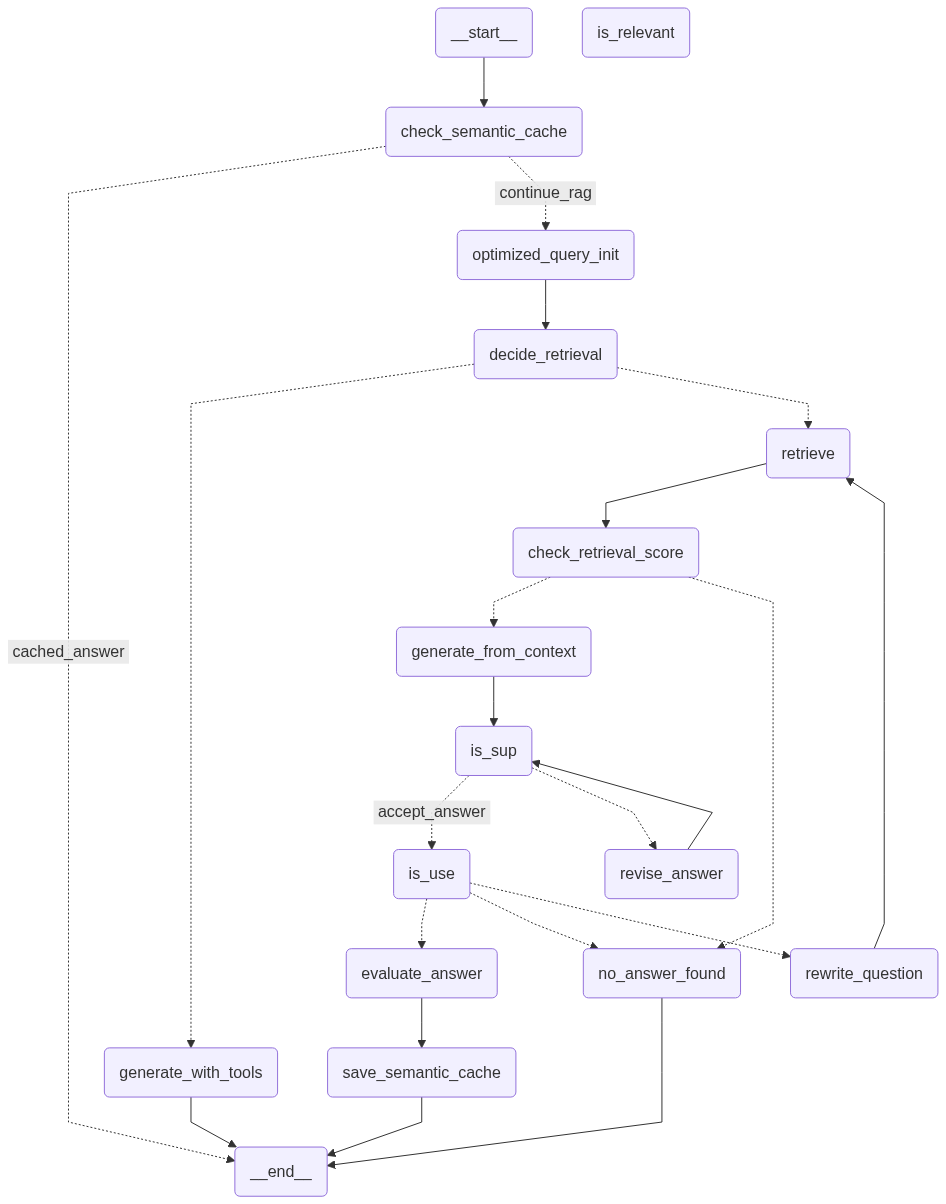

In [30]:
# -----------------------------
# Build graph (UPDATED: IsUSE -> if not useful -> rewrite -> retrieve; else END)
# -----------------------------

def graph():
    g = StateGraph(State)

    # --------------------
    # Nodes
    # --------------------
    g.add_node("check_semantic_cache", check_semantic_cache_node)
    g.add_node("optimized_query_init", optimizer_retrieval_node)
    g.add_node("decide_retrieval", decide_retrieval)
    # g.add_node("generate_direct", generate_direct)
    g.add_node("generate_with_tools", generate_with_tools)
    g.add_node("retrieve", retrieve)
    # g.add_node("web_search_node", web_search_node)

    g.add_node("is_relevant", is_relevant)
    g.add_node("check_retrieval_score", check_retrieval_score)

    g.add_node("generate_from_context", generate_from_context)
    g.add_node("no_answer_found", no_answer_found)

    # IsSUP + revise loop
    g.add_node("is_sup", is_sup)
    g.add_node("revise_answer", revise_answer)

    # IsUSE
    g.add_node("is_use", is_use)

    # ✅ NEW: rewrite question for better retrieval
    g.add_node("rewrite_question", rewrite_question)

    # evalution_node
    g.add_node("evaluate_answer", evaluate_answer_node)
    g.add_node("save_semantic_cache",save_semantic_cache_node)


    # --------------------
    # Edges
    # --------------------

    g.add_edge(START,"check_semantic_cache")
    g.add_conditional_edges(
    "check_semantic_cache",
    route_after_cache,
    {
        "cached_answer": END,
        "continue_rag": "optimized_query_init",
    }
    )
    g.add_edge("optimized_query_init","decide_retrieval")
    # g.add_edge("decide_retrieval", "optimized_query_init")

    g.add_conditional_edges(
        "decide_retrieval",
        route_after_decide,
        {"generate_with_tools": "generate_with_tools", "retrieve": "retrieve"},
    )

    g.add_edge("generate_with_tools", END)

    # Retrieve -> relevance -> (generate | no_answer_found)
    # g.add_edge("retrieve", "is_relevant")
    g.add_edge("retrieve", "check_retrieval_score")


    g.add_conditional_edges(
        # "is_relevant",
        "check_retrieval_score",
        route_after_relevance,
        {
            "generate_from_context": "generate_from_context",
            "no_answer_found": "no_answer_found",
        },
    )

    g.add_edge("no_answer_found", END)

    # --------------------
    # Generate -> IsSUP -> (IsUSE | revise) loop
    # --------------------
    g.add_edge("generate_from_context", "is_sup")

    g.add_conditional_edges(
        "is_sup",
        route_after_issup,
        {
            "accept_answer": "is_use",      # fully_supported (or max retries) -> go to IsUSE
            "revise_answer": "revise_answer",
        },
    )

    g.add_edge("revise_answer", "is_sup")  # 🔁 loop back to IsSUP

    # --------------------
    # IsUSE routing
    #   - useful -> evaluate_answer
    #   - not_useful -> rewrite_question -> retrieve (try again)
    #   - give up -> no_answer_found -> END
    # --------------------
    g.add_conditional_edges(
        "is_use",
        route_after_isuse,
        {
            "evaluate_answer": "evaluate_answer",
            # "END": END,
            "rewrite_question": "rewrite_question",
            "no_answer_found": "no_answer_found",
        },
    )

    # rewrite -> retrieve -> relevance -> ...
    g.add_edge("rewrite_question", "retrieve")
    # g.add_edge("evaluate_answer", END)
    g.add_edge("evaluate_answer","save_semantic_cache")

    g.add_edge("save_semantic_cache",END)

    app = g.compile()

    return app

app = graph()
app


In [31]:
# -----------------------------
# Run the graph
# -----------------------------
initial_state = {
    "question": "Who is Bappy AI Engineer?",
    "retrieval_query":"",  # ✅ important
    "rewrite_tries": 0,                                        # ✅ important
    "docs": [],
    "relevant_docs": [],
    "context": "",
    "answer": "",
    "issup": "",
    "evidence": [],
    "retries": 0,
    "isuse": "useful",
    "use_reason": "",
}


result = app.invoke(
    initial_state,
    config={"recursion_limit": 80},  # allow revise → verify loops
)

# -----------------------------
# Debug / inspection output (clean + complete)
# -----------------------------
print("\n===== RAG EXECUTION RESULT =====\n")

print("Question:", initial_state.get("question"))
print("Need Retrieval:", result.get("need_retrieval"))

# If you added these counters/fields in your State:
print("Rewrite tries (retrieval):", result.get("rewrite_tries", 0))
print("Support revise tries:", result.get("retries", 0))

print("\nRetrieval:")
print("  Total retrieved docs:", len(result.get("docs", []) or []))
print("  Relevant docs:", len(result.get("relevant_docs", []) or []))

# Optional: show sources/pages for relevant docs
relevant_docs = result.get("relevant_docs", []) or []
if relevant_docs:
    print("\nRelevant docs (source/page):")
    for i, d in enumerate(relevant_docs, 1):
        src = (d.metadata or {}).get("source", "unknown")
        page = (d.metadata or {}).get("page", None)
        title = (d.metadata or {}).get("title", "")
        extra = f", title={title}" if title else ""
        if page is not None:
            print(f"  {i}. source={src}, page={page}{extra}")
        else:
            print(f"  {i}. source={src}{extra}")

print("\nVerification (IsSUP):")
print("  issup:", result.get("issup"))
evidence = result.get("evidence", []) or []
if evidence:
    print("  evidence:")
    for e in evidence:
        print("   -", e)
else:
    print("  evidence: (none)")

print("\nUsefulness (IsUSE):")
print("  isuse:", result.get("isuse"))
print("  reason:", result.get("use_reason", ""))

print("\nFinal Answer:")
print(result.get("answer"))

print("\n===============================\n")



🔎 SEMANTIC CACHE CHECK
Question: Who is Bappy AI Engineer?
❌ CACHE MISS
Similarity: < threshold

========== QUERY OPTIMIZER ==========
Original: Who is Bappy AI Engineer?
Optimized: Bappy AI Engineer
Keywords: ['Bappy', 'AI', 'Engineer']
Entities: ['Bappy']

===== RAG EXECUTION RESULT =====

Question: Who is Bappy AI Engineer?
Need Retrieval: True
Rewrite tries (retrieval): 0
Support revise tries: 0

Retrieval:
  Total retrieved docs: 4
  Relevant docs: 0

Verification (IsSUP):
  issup: 
  evidence: (none)

Usefulness (IsUSE):
  isuse: useful
  reason: 

Final Answer:
No answer found.




In [25]:
# -----------------------------
# Run the graph
# -----------------------------
initial_state = {
    "question": "Who is Tanvir Ahmed AI Engineer?",
    "retrieval_query":"",  # ✅ important
    "rewrite_tries": 0,                                        # ✅ important
    "docs": [],
    "relevant_docs": [],
    "context": "",
    "answer": "",
    "issup": "",
    "evidence": [],
    "retries": 0,
    "isuse": "useful",
    "use_reason": "",
}


result = app.invoke(
    initial_state,
    config={"recursion_limit": 80},  # allow revise → verify loops
)

# -----------------------------
# Debug / inspection output (clean + complete)
# -----------------------------
print("\n===== RAG EXECUTION RESULT =====\n")

print("Question:", initial_state.get("question"))
print("Need Retrieval:", result.get("need_retrieval"))

# If you added these counters/fields in your State:
print("Rewrite tries (retrieval):", result.get("rewrite_tries", 0))
print("Support revise tries:", result.get("retries", 0))

print("\nRetrieval:")
print("  Total retrieved docs:", len(result.get("docs", []) or []))
print("  Relevant docs:", len(result.get("relevant_docs", []) or []))

# Optional: show sources/pages for relevant docs
relevant_docs = result.get("relevant_docs", []) or []
if relevant_docs:
    print("\nRelevant docs (source/page):")
    for i, d in enumerate(relevant_docs, 1):
        src = (d.metadata or {}).get("source", "unknown")
        page = (d.metadata or {}).get("page", None)
        title = (d.metadata or {}).get("title", "")
        extra = f", title={title}" if title else ""
        if page is not None:
            print(f"  {i}. source={src}, page={page}{extra}")
        else:
            print(f"  {i}. source={src}{extra}")

print("\nVerification (IsSUP):")
print("  issup:", result.get("issup"))
evidence = result.get("evidence", []) or []
if evidence:
    print("  evidence:")
    for e in evidence:
        print("   -", e)
else:
    print("  evidence: (none)")

print("\nUsefulness (IsUSE):")
print("  isuse:", result.get("isuse"))
print("  reason:", result.get("use_reason", ""))

print("\nFinal Answer:")
print(result.get("answer"))

print("\n===============================\n")



🔎 SEMANTIC CACHE CHECK
Question: Who is Tanvir Ahmed AI Engineer?
Semantic cache HIT (similarity=1.000)(Cached question: Who is Tanvir Ahmed AI Engineer?)

===== RAG EXECUTION RESULT =====

Question: Who is Tanvir Ahmed AI Engineer?
Need Retrieval: None
Rewrite tries (retrieval): 0
Support revise tries: 0

Retrieval:
  Total retrieved docs: 0
  Relevant docs: 0

Verification (IsSUP):
  issup: 
  evidence: (none)

Usefulness (IsUSE):
  isuse: useful
  reason: 

Final Answer:
Tanvir Ahmed is an AI Engineer and Machine Learning Engineer based in Dhaka, Bangladesh. He specializes in end-to-end AI systems, particularly in the areas of Machine Learning and Generative AI. He is employed full-time and holds the employee ID EMP-001.




In [72]:
# -----------------------------
# Run the graph
# -----------------------------
initial_state = {
    "question": "Who is Tanvir?",
    "retrieval_query":"",  # ✅ important
    "rewrite_tries": 0,                                        # ✅ important
    "docs": [],
    "relevant_docs": [],
    "context": "",
    "answer": "",
    "issup": "",
    "evidence": [],
    "retries": 0,
    "isuse": "useful",
    "use_reason": "",
}


result = app.invoke(
    initial_state,
    config={"recursion_limit": 80},  # allow revise → verify loops
)

# -----------------------------
# Debug / inspection output (clean + complete)
# -----------------------------
print("\n===== RAG EXECUTION RESULT =====\n")

print("Question:", initial_state.get("question"))
print("Need Retrieval:", result.get("need_retrieval"))

# If you added these counters/fields in your State:
print("Rewrite tries (retrieval):", result.get("rewrite_tries", 0))
print("Support revise tries:", result.get("retries", 0))

print("\nRetrieval:")
print("  Total retrieved docs:", len(result.get("docs", []) or []))
print("  Relevant docs:", len(result.get("relevant_docs", []) or []))

# Optional: show sources/pages for relevant docs
relevant_docs = result.get("relevant_docs", []) or []
if relevant_docs:
    print("\nRelevant docs (source/page):")
    for i, d in enumerate(relevant_docs, 1):
        src = (d.metadata or {}).get("source", "unknown")
        page = (d.metadata or {}).get("page", None)
        title = (d.metadata or {}).get("title", "")
        extra = f", title={title}" if title else ""
        if page is not None:
            print(f"  {i}. source={src}, page={page}{extra}")
        else:
            print(f"  {i}. source={src}{extra}")

print("\nVerification (IsSUP):")
print("  issup:", result.get("issup"))
evidence = result.get("evidence", []) or []
if evidence:
    print("  evidence:")
    for e in evidence:
        print("   -", e)
else:
    print("  evidence: (none)")

print("\nUsefulness (IsUSE):")
print("  isuse:", result.get("isuse"))
print("  reason:", result.get("use_reason", ""))

print("\nFinal Answer:")
print(result.get("answer"))

print("\n===============================\n")



🔎 SEMANTIC CACHE CHECK
Question: Who is Tanvir?
❌ CACHE MISS
Similarity: < threshold

========== IsSUP ==========
Question: Who is Tanvir?
Answer: Tanvir's manager is the Department Head, who leads the Department.
IsSUP: fully_supported
Evidence:
 - Tanvir → Department → Department Head.

========== ROUTE AFTER ISSUP ==========
IsSUP: fully_supported
Retries: 0
➡️ ACCEPT ANSWER

========== IsUSE ==========
Question: Who is Tanvir?
Answer: Tanvir's manager is the Department Head, who leads the Department.
IsUSE: not_useful
Reason: The answer does not provide information about who Tanvir is.

========== ROUTE AFTER ISUSE ==========
IsUSE: not_useful
Rewrite tries: 0
➡️ REWRITE QUESTION

========== IsSUP ==========
Question: Who is Tanvir?
Answer: Tanvir is the Department Head.
IsSUP: fully_supported
Evidence:
 - Tanvir → Department → Department Head.

========== ROUTE AFTER ISSUP ==========
IsSUP: fully_supported
Retries: 0
➡️ ACCEPT ANSWER

========== IsUSE ==========
Question: Who is 

In [26]:
for event in app.stream({"question": "Who is Tanvir?"},stream_mode="updates"):

    print("\n" + "=" * 60)

    for node, update in event.items():

        print(f"🔵 EXECUTED: {node}")

        if isinstance(update, dict):

            if "need_retrieval" in update:
                print("   Need Retrieval:",update["need_retrieval"])

            if "retrieved_docs" in update:
                print("   Retrieved:",len(update["retrieved_docs"]))

            if "relevant_docs" in update:
                print("   Relevant:",len(update["relevant_docs"]))

            if "answer" in update:
                print("   Answer:",update["answer"])

            if "issup" in update:
                print("   IsSUP:",update["issup"])

            if "isuse" in update:
                print("   IsUSE:",update["isuse"])

            if "evaluation" in update:
                print("   Evaluation:",update["evaluation"])


🔎 SEMANTIC CACHE CHECK
Question: Who is Tanvir?
Semantic cache HIT (similarity=1.000)(Cached question: Who is Tanvir?)

🔵 EXECUTED: check_semantic_cache
   Answer: Tanvir is the Department Head.
   Evaluation: {'hallucination': {'hallucination_score': 0.75, 'hallucinated_claims': ['Tanvir is the Department Head.'], 'supported_claims': [], 'reasoning': "The claim that 'Tanvir is the Department Head' is not directly supported by the context provided. While it mentions 'Tanvir → Department → Department Head', it does not explicitly state that Tanvir holds the title of Department Head. Therefore, this claim is considered hallucinated."}, 'groundedness': {'groundedness_score': 0.75, 'evidence_alignment': 0.75, 'completeness': 0.75, 'accuracy': 0.75, 'relevance': 1.0, 'reasoning': "The answer states that Tanvir is the Department Head, which is supported by the context that indicates Tanvir's role. However, the context does not provide additional details about Tanvir, such as their job title

In [ ]:
for event in app.stream({"question": "Who is Tanvir AIEnginner?"},stream_mode="updates"):

    print("\n" + "=" * 60)

    for node, update in event.items():

        print(f"🔵 EXECUTED: {node}")

        if isinstance(update, dict):

            if "need_retrieval" in update:
                print("   Need Retrieval:",update["need_retrieval"])

            if "retrieved_docs" in update:
                print("   Retrieved:",len(update["retrieved_docs"]))

            if "relevant_docs" in update:
                print("   Relevant:",len(update["relevant_docs"]))

            if "answer" in update:
                print("   Answer:",update["answer"])

            if "issup" in update:
                print("   IsSUP:",update["issup"])

            if "isuse" in update:
                print("   IsUSE:",update["isuse"])

            if "evaluation" in update:
                print("   Evaluation:",update["evaluation"])


🔵 EXECUTED: decide_retrieval
   Need Retrieval: True

🔵 EXECUTED: retrieve

🔵 EXECUTED: is_relevant
   Relevant: 4

🔵 EXECUTED: generate_from_context
   Answer: Tanvir Ahmed is an AI Engineer and Machine Learning Engineer based in Dhaka, Bangladesh. He specializes in end-to-end AI systems and has expertise in generative AI.

🔵 EXECUTED: is_sup
   IsSUP: fully_supported

========== ROUTE AFTER ISUSE ==========
IsUSE: useful
Rewrite tries: 0
➡️ EVALUATE ANSWER

🔵 EXECUTED: is_use
   IsUSE: useful

========== EVALUATE ANSWER ==========
Question: Who is Tanvir AIEnginner?
Answer: Tanvir Ahmed is an AI Engineer and Machine Learning Engineer based in Dhaka, Bangladesh. He specializes in end-to-end AI systems and has expertise in generative AI.
Relevant docs: 4
Evaluation: {'hallucination': {'hallucination_score': 0.0, 'hallucinated_claims': [], 'supported_claims': ['Tanvir Ahmed is an AI Engineer and Machine Learning Engineer based in Dhaka, Bangladesh.', 'He specializes in end-to-end AI sy

In [73]:
question = "who is Bappy Ahmed"

for event in app.stream({"question": question},stream_mode="updates"):

    print("\n" + "=" * 60)

    for node, update in event.items():

        print(f"🔵 EXECUTED: {node}")

        if isinstance(update, dict):

            if "need_retrieval" in update:
                print("   Need Retrieval:",update["need_retrieval"])

            if "retrieved_docs" in update:
                print("   Retrieved:",len(update["retrieved_docs"]))

            if "relevant_docs" in update:
                print("   Relevant:",len(update["relevant_docs"]))

            if "answer" in update:
                print("   Answer:",update["answer"])

            if "issup" in update:
                print("   IsSUP:",update["issup"])

            if "isuse" in update:
                print("   IsUSE:",update["isuse"])

            if "evaluation" in update:
                print("   Evaluation:",update["evaluation"])


🔎 SEMANTIC CACHE CHECK
Question: who is Bappy Ahmed
❌ CACHE MISS
Similarity: < threshold

🔵 EXECUTED: check_semantic_cache

🔵 EXECUTED: decide_retrieval
   Need Retrieval: False

🔵 EXECUTED: generate_direct
   Answer: I don't know based on my general knowledge.


In [74]:
question = "Professional Profile Tanvir Ahmed"

for event in app.stream({"question": question},stream_mode="updates"):

    print("\n" + "=" * 60)

    for node, update in event.items():

        print(f"🔵 EXECUTED: {node}")

        if isinstance(update, dict):

            if "need_retrieval" in update:
                print("   Need Retrieval:",update["need_retrieval"])

            if "retrieved_docs" in update:
                print("   Retrieved:",len(update["retrieved_docs"]))

            if "relevant_docs" in update:
                print("   Relevant:",len(update["relevant_docs"]))

            if "answer" in update:
                print("   Answer:",update["answer"])

            if "issup" in update:
                print("   IsSUP:",update["issup"])

            if "isuse" in update:
                print("   IsUSE:",update["isuse"])

            if "evaluation" in update:
                print("   Evaluation:",update["evaluation"])


🔎 SEMANTIC CACHE CHECK
Question: Professional Profile Tanvir Ahmed
❌ CACHE MISS
Similarity: < threshold

🔵 EXECUTED: check_semantic_cache

🔵 EXECUTED: decide_retrieval
   Need Retrieval: True

🔵 EXECUTED: retrieve

🔵 EXECUTED: is_relevant
   Relevant: 4

🔵 EXECUTED: generate_from_context
   Answer: Tanvir Ahmed is an AI Engineer / Machine Learning Engineer specializing in end-to-end AI systems. He is based in Dhaka, Bangladesh. However, the specific details regarding his team, office location, employment type, annual salary, monthly gross salary, job title, company in the demo database, department, manager, and team are not provided in the available information.

========== IsSUP ==========
Question: Professional Profile Tanvir Ahmed
Answer: Tanvir Ahmed is an AI Engineer / Machine Learning Engineer specializing in end-to-end AI systems. He is based in Dhaka, Bangladesh. However, the specific details regarding his team, office location, employment type, annual salary, monthly gross sa